## Global Configuration

In [1]:
dataset_root = "../datasets"

import sys

sys.path.append("../src/")  # analytics package

%load_ext autoreload
%autoreload 2
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

## PyTorch Model Definition

- [Flower PyTorch Example](https://github.com/flwrlabs/flower/blob/main/examples/flower-in-30-minutes/tutorial.ipynb)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(
        self,
        input_dim: int,
        encoding_dim: int,
        conv_input_size: int = 20,
        intermediate_dim: int = 64,
        activation_fn = F.relu,
        output_activation_fn = torch.sigmoid
    ):
        super(Net, self).__init__()

        if conv_input_size <= 0 or conv_input_size > input_dim:
            raise ValueError(f"conv_input_size must be in [1, {input_dim}], got {conv_input_size}")

        self.conv_input_size = conv_input_size
        self.activation_fn = activation_fn
        self.output_activation_fn = output_activation_fn

        # --- Encoder Branches ---
        # Conv Branch: Input (Batch, 1, conv_input_size)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        # Calculate Flatten size after Conv/Pool
        # Formula: L_out = floor((L_in - kernel_size) / stride + 1)
        conv_out_size = (conv_input_size - 3) // 1 + 1
        pool_out_size = conv_out_size // 2
        self.flat_size = 32 * pool_out_size

        # Dense Branch: Remaining features
        self.remaining_dim = input_dim - conv_input_size
        self.dense_branch = nn.Linear(self.remaining_dim, intermediate_dim)

        # --- Shared Encoder Hidden Layers ---
        self.enc_hidden = nn.Linear(self.flat_size + intermediate_dim, intermediate_dim)
        self.latent = nn.Linear(intermediate_dim, encoding_dim)

        # --- Decoder ---
        self.dec_hidden = nn.Linear(encoding_dim, intermediate_dim)
        self.recon = nn.Linear(intermediate_dim, input_dim)

        # Apply Xavier Uniform initialization to match Keras defaults
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Conv1d)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def encode(self, x):
        # Slice 1: Convolutional part
        # Keras: (batch, length) -> (batch, length, 1)
        # PyTorch: (batch, length) -> (batch, 1, length)
        x_conv = x[:, :self.conv_input_size].unsqueeze(1)
        x_conv = self.activation_fn(self.conv1(x_conv))
        x_conv = self.pool1(x_conv)
        x_conv = torch.flatten(x_conv, start_dim=1)

        # Slice 2: Dense part
        x_dense = x[:, self.conv_input_size:]
        x_dense = self.activation_fn(self.dense_branch(x_dense))

        # Combine and Bottleneck
        combined = torch.cat([x_conv, x_dense], dim=1)
        hidden = self.activation_fn(self.enc_hidden(combined))
        return self.activation_fn(self.latent(hidden))

    def decode(self, z):
        hidden_dec = self.activation_fn(self.dec_hidden(z))
        return self.output_activation_fn(self.recon(hidden_dec))

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

## Training Engine

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy

def train_autoencoder_pytorch(
    model,
    x_train,
    x_val,
    max_epochs=50,
    batch_size=16,
    lr=1e-3,
    early_stopping_patience=10,
    device="cpu",
):
    # Prepare DataLoaders (Equivalent to Keras x_train, x_train)
    t_train = torch.tensor(x_train, dtype=torch.float32)
    t_val = torch.tensor(x_val, dtype=torch.float32)

    train_loader = DataLoader(
        TensorDataset(t_train), batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(TensorDataset(t_val), batch_size=batch_size)

    # Setup Optimizer and Loss
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    model.to(device)

    # Early Stopping Variables
    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0

    history = {"loss": [], "val_loss": []}

    for epoch in range(max_epochs):
        # --- Training Phase ---
        model.train()
        train_loss = 0.0
        for [batch] in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            outputs = model(batch)
            loss = criterion(outputs, batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch.size(0)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for [v_batch] in val_loader:
                v_batch = v_batch.to(device)
                v_outputs = model(v_batch)
                v_loss = criterion(v_outputs, v_batch)
                val_loss += v_loss.item() * v_batch.size(0)

        avg_train_loss = train_loss / len(t_train)
        avg_val_loss = val_loss / len(t_val)

        history["loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)

        # Log progress (Equivalent to verbose=1)
        if (epoch + 1) % 5 == 0:
            print(
                f"Epoch {epoch + 1}/{max_epochs} - loss: {avg_train_loss:.4f} - val_loss: {avg_val_loss:.4f}"
            )

        # --- Early Stopping Logic ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break

    # Restore best weights (Equivalent to restore_best_weights=True)
    model.load_state_dict(best_model_wts)
    return history


## Dataset loading and preparation

In [4]:
import pyarrow.compute as pc
from tls_profiling.preprocessing import build_and_fit_preprocessor, extract_features
from tls_profiling.io import open_tls_parquet_dataset

dataset = open_tls_parquet_dataset(f"{dataset_root}/malware.parquet")

filt = (
    pc.starts_with(
        pc.field("meta.sample.id"), "25090"
    )  # use meta.sample.id to get only a single day 2025-09-01
)

print(f"Loading dataset...filter={filt}")
df = dataset.to_table(filter=filt).to_pandas()

df.head(10)

Loading dataset...filter=starts_with(meta.sample.id, {pattern="25090", ignore_case=false})


,bs,ps,br,pr,dp,sp,da,sa,ts,td,...,tls.ja4,tls.ja3s,tls.ja4s,meta.sample.id,meta.malware.family,meta.system.os,meta.system.service,meta.application.name,meta.application.process,tls.rec
0,1262,13,8316,12,443,49792,20.72.205.209,10.127.0.189,1.756762e+09,0.941528,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -2..."
1,49974,64,39987,54,443,49801,40.126.31.67,10.127.0.189,1.756762e+09,128.561234,...,t12d1909h2_d83cc789557e_7af1ed941c26,7d8fd34fdb13a7fff30d5a52846b6c4c,t120400_c030_09f674154ab3,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,None,None,None,"[-226, 3954, -102, -1, -40, 1, 40, -445, -3616..."
2,35832,48,31235,40,443,49803,40.126.31.67,10.127.0.189,1.756762e+09,138.264477,...,t12d1909h2_d83cc789557e_7af1ed941c26,7d8fd34fdb13a7fff30d5a52846b6c4c,t120400_c030_09f674154ab3,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,None,None,None,"[-226, 3954, -102, -1, -40, 1, 40, -469, -7637..."
3,4529,14,8280,14,443,49804,20.72.205.209,10.127.0.189,1.756762e+09,1.195099,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -1..."
4,4035,14,4910,13,443,49806,52.167.17.97,10.127.0.189,1.756762e+09,0.749950,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -1..."
5,1982,13,4870,12,443,49807,52.167.17.97,10.127.0.189,1.756762e+09,0.683508,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -9..."
6,2437,19,21862,25,443,49808,52.167.17.97,10.127.0.189,1.756762e+09,0.657093,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -1..."
7,1775,25,28988,27,443,49860,74.178.76.128,10.127.0.189,1.756762e+09,0.216118,...,t12d1909h2_d83cc789557e_7af1ed941c26,a02d7ceb8c8cbb4da2e6007f5a1c91e4,t1203h2_c02c_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_core,None,None,"[-206, 2488, -102, -1, -40, 1, 40, -82, -264, ..."
8,1134,13,3326,10,443,49861,13.95.31.18,10.127.0.189,1.756762e+09,0.235395,...,t12d1909h2_d83cc789557e_7af1ed941c26,87b9bed0515be16c82bdc44d88a4a0ec,t1204h2_c02c_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_delivery,None,None,"[-211, 2550, -102, -1, -40, 1, 40, 64, -82, -9..."
9,996,10,3239,8,443,49862,74.178.76.128,10.127.0.189,1.756762e+09,0.173583,...,t12d1909h2_d83cc789557e_7af1ed941c26,a02d7ceb8c8cbb4da2e6007f5a1c91e4,t1203h2_c02c_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_core,None,None,"[-206, 2487, -102, -1, -40, 1, 40, -82, -85, 5..."


## Traing a collection of AEs

In [16]:
MIN_SAMPLES = 100
MAX_SAMPLES = 1_000
MAX_FAMILIES = 10
VAL_RATIO = 0.2
TEST_RATIO = 0.2
ENCODING_DIM = 10
TRAINING_EPOCHS = 20
PATIENCE = 10

from sklearn.preprocessing import MinMaxScaler
from tls_profiling.preprocessing.malware_families import get_families, per_family_split

import warnings

warnings.filterwarnings("ignore", category=UserWarning)
print(f" Getting family splits...")

families = get_families(df)
splits = per_family_split(df, families, test_size=TEST_RATIO)

models = {}  # <-- store trained models here

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for family, (pre_train_df, test_df) in splits.items():
    pre_train_df = pre_train_df.sort_values("ts", kind="mergesort")
    split_idx = int((1 - VAL_RATIO) * len(pre_train_df))
    train_df = pre_train_df.iloc[:split_idx]
    val_df = pre_train_df.iloc[split_idx:]

    if len(train_df) > MIN_SAMPLES:
        if len(train_df) > MAX_SAMPLES:
            train_df = train_df.sample(MAX_SAMPLES, random_state=1234)

        # Preprocessing
        pipeline = build_and_fit_preprocessor(extract_features(train_df))
        X_train = pipeline.transform(extract_features(train_df))
        X_val = pipeline.transform(extract_features(val_df))
        X_test = pipeline.transform(extract_features(test_df))

        # Safety Scaller for BCELoss
        # This catches any columns passed through by 'remainder' or float precision errors
        final_scaler = MinMaxScaler(feature_range=(0, 1))
        X_train = final_scaler.fit_transform(X_train)
        X_val   = final_scaler.transform(X_val)
        X_test  = final_scaler.transform(X_test)
        # Clip to handle tiny floating point overflow (e.g. 1.000000000002)
        X_train = np.clip(X_train, 0, 1)
        X_val   = np.clip(X_val, 0, 1)
        X_test  = np.clip(X_test, 0, 1)

        # 1. Initialize PyTorch Net
        net_model = Net(input_dim=X_train.shape[1], encoding_dim=ENCODING_DIM)

        # 2. Train using the PyTorch utility
        history = train_autoencoder_pytorch(
            model=net_model,
            x_train=X_train,
            x_val=X_val,
            max_epochs=TRAINING_EPOCHS,
            early_stopping_patience=PATIENCE,
            device=device,
        )

        # 3. Final Test Evaluation
        net_model.eval()
        with torch.no_grad():
            t_test = torch.tensor(X_test, dtype=torch.float32).to(device)
            recon = net_model(t_test)
            test_mse = nn.MSELoss()(recon, t_test).item()

        models[family] = {
            "model": net_model, 
            "history": history, 
            "test_loss": test_mse,
            "pipeline": pipeline,
            "safety_scaler": final_scaler
        }
        print(f"Family {family} complete. Test MSE: {test_mse:.6f}")

    if len(models) >= MAX_FAMILIES:
        break


models

 Getting family splits...
Epoch 5/20 - loss: 0.0483 - val_loss: 0.0396
Epoch 10/20 - loss: 0.0380 - val_loss: 0.0361
Epoch 15/20 - loss: 0.0357 - val_loss: 0.0349
Epoch 20/20 - loss: 0.0348 - val_loss: 0.0340
Family ades_stealer complete. Test MSE: 0.000214
Epoch 5/20 - loss: 0.0521 - val_loss: 0.0361
Epoch 10/20 - loss: 0.0455 - val_loss: 0.0332
Epoch 15/20 - loss: 0.0390 - val_loss: 0.0294
Epoch 20/20 - loss: 0.0349 - val_loss: 0.0282
Family agenttesla complete. Test MSE: 0.030577
Epoch 5/20 - loss: 0.0859 - val_loss: 0.0832
Epoch 10/20 - loss: 0.0752 - val_loss: 0.0738
Epoch 15/20 - loss: 0.0717 - val_loss: 0.0719
Epoch 20/20 - loss: 0.0715 - val_loss: 0.0708
Family amadey complete. Test MSE: 0.001094
Epoch 5/20 - loss: 0.0899 - val_loss: 0.0841
Epoch 10/20 - loss: 0.0813 - val_loss: 0.0782
Epoch 15/20 - loss: 0.0764 - val_loss: 0.0734
Epoch 20/20 - loss: 0.0744 - val_loss: 0.0727
Family asyncrat complete. Test MSE: 0.001567
Epoch 5/20 - loss: 0.1158 - val_loss: 0.1225
Epoch 10/20 -

{'ades_stealer': {'model': Net(
    (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,))
    (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (dense_branch): Linear(in_features=137, out_features=64, bias=True)
    (enc_hidden): Linear(in_features=352, out_features=64, bias=True)
    (latent): Linear(in_features=64, out_features=10, bias=True)
    (dec_hidden): Linear(in_features=10, out_features=64, bias=True)
    (recon): Linear(in_features=64, out_features=157, bias=True)
  ),
  'history': {'loss': [0.3283136565558511,
    0.08118520404014112,
    0.06215566175892882,
    0.05238316734047497,
    0.04825003067562483,
    0.04493964298278498,
    0.04268426436307204,
    0.040737440969744416,
    0.03908104601219229,
    0.038042999702880824,
    0.037340750184533825,
    0.036705164854073415,
    0.036417281937814946,
    0.03598463071754615,
    0.0356835497551644,
    0.03551296979121493,
    0.03513198148678331,
    0.034981968370160904,
   

## Evaluation of AEs using the input dataset

In [17]:
import torch
import numpy as np
import pandas as pd
import warnings

# Silence the FutureWarnings and opt-in to new pandas behavior
pd.set_option('future.no_silent_downcasting', True)
warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------------------
# Helper: compute AE reconstruction error (PyTorch Version)
# ---------------------------------------------------------------------
def compute_recon_error(model, X, device="cpu"):
    """Compute reconstruction error for PyTorch autoencoder model."""
    model.eval()
    model.to(device)

    # Convert numpy input to torch tensor
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

    with torch.no_grad():
        recon = model(X_tensor)
        # Move back to cpu/numpy for error calculation
        recon = recon.cpu().numpy()

    # Compute MSE per sample: mean((original - reconstructed)^2) across features
    return np.mean((X - recon) ** 2, axis=1)


# ---------------------------------------------------------------------
# EVALUATION: model (trained on fam A) → tested on fam B
# ---------------------------------------------------------------------
results = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=== Pre-calculating features for all families ===")
# Cache extracted features to avoid redundant calls and warnings
test_features_cache = {}
for fam, (_, test_df) in splits.items():
    # extract_features is called once per family here
    test_features_cache[fam] = extract_features(test_df)

print("\n=== Evaluating PyTorch models across all families ===")

# Families to evaluate on
target_families = list(splits.keys())

for model_family, result_dict in models.items():
    # Access the PyTorch model from the dictionary structure created earlier
    model = result_dict["model"]
    pipeline = result_dict["pipeline"] 
    safety_scaler = result_dict["safety_scaler"]

    if model is None:
        print(f"Skipping evaluation for '{model_family}' (no trained model).")
        continue

    print(f"\nEvaluating PyTorch model trained on: {model_family}")

    # Baseline: reconstruction error on its own family
    # Note: We must use the pipeline specific to the model_family to transform
    # Assuming 'pipeline' in the outer scope is the one fit for the current model_family
    # Or better, if you saved it: pipeline = result_dict["pipeline"]

    X_self = pipeline.transform(test_features_cache[model_family])
    X_self = np.clip(safety_scaler.transform(X_self), 0, 1)
    err_self = compute_recon_error(model, X_self, device=device)

    self_mean = np.mean(err_self)
    self_std  = np.std(err_self) + 1e-9

    # Evaluate on all other families
    for target_family in target_families:
        # Transform the cached features using the current model's pipeline
        X_target = pipeline.transform(test_features_cache[target_family])
        X_target = np.clip(safety_scaler.transform(X_target), 0, 1)

        err = compute_recon_error(model, X_target, device=device)

        row = {
            "model_family": model_family,
            "target_family": target_family,
            "mean": float(np.mean(err)),
            "std": float(np.std(err)),
            "median": float(np.median(err)),
            "p90": float(np.percentile(err, 90)),
            "p95": float(np.percentile(err, 95)),
            "p99": float(np.percentile(err, 99)),
            "delta_mean": float(np.mean(err) - self_mean),
            "z_mean": float((np.mean(err) - self_mean) / self_std),
        }

        results.append(row)

# Convert to DataFrame
df_eval = pd.DataFrame(results)
print("\nEvaluation results:\n", df_eval.head())

=== Pre-calculating features for all families ===

=== Evaluating PyTorch models across all families ===

Evaluating PyTorch model trained on: ades_stealer

Evaluating PyTorch model trained on: agenttesla

Evaluating PyTorch model trained on: amadey

Evaluating PyTorch model trained on: asyncrat

Evaluating PyTorch model trained on: azorult

Evaluating PyTorch model trained on: blackmoon

Evaluating PyTorch model trained on: blankgrabber

Evaluating PyTorch model trained on: chaos

Evaluating PyTorch model trained on: cobaltstrike

Evaluating PyTorch model trained on: dcrat

Evaluation results:
    model_family target_family      mean       std    median       p90  \
0  ades_stealer  ades_stealer  0.000214  0.000863  0.000024  0.000094   
1  ades_stealer    agenttesla  0.022562  0.055446  0.001154  0.048058   
2  ades_stealer        amadey  0.038807  0.071444  0.000314  0.172542   
3  ades_stealer      asyncrat  0.031130  0.062058  0.000314  0.162609   
4  ades_stealer       aurotun  0

##  Heatmap Visualization

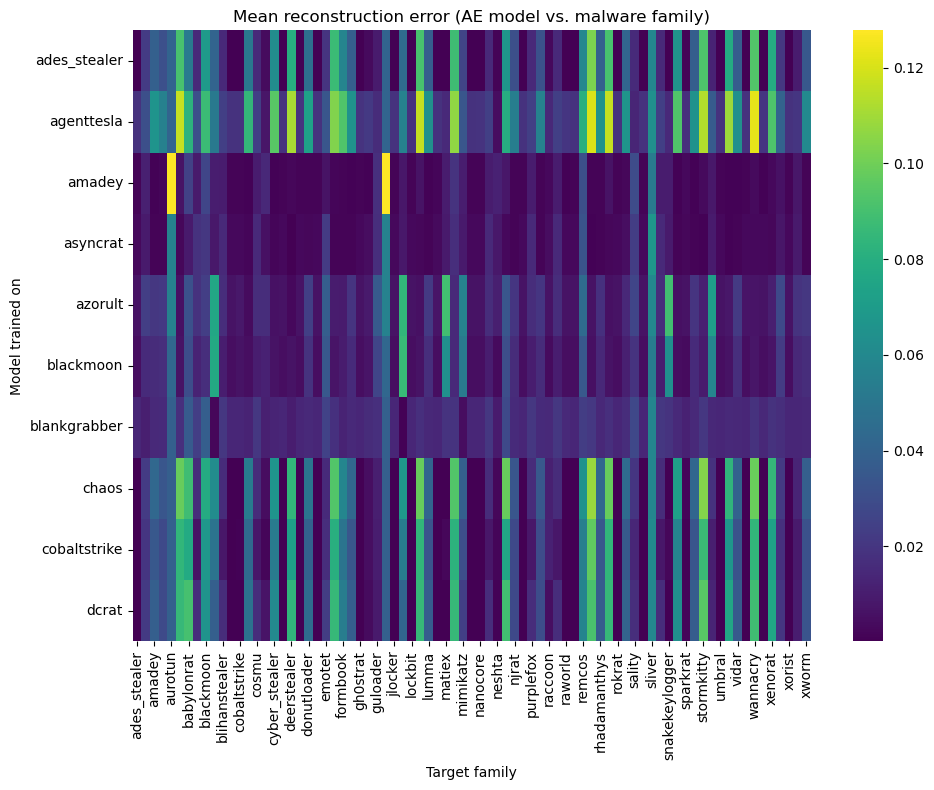

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot_mean = df_eval.pivot(index="model_family", columns="target_family", values="mean")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_mean, annot=False, cmap="viridis")
plt.title("Mean reconstruction error (AE model vs. malware family)")
plt.xlabel("Target family")
plt.ylabel("Model trained on")
plt.tight_layout()
plt.show()

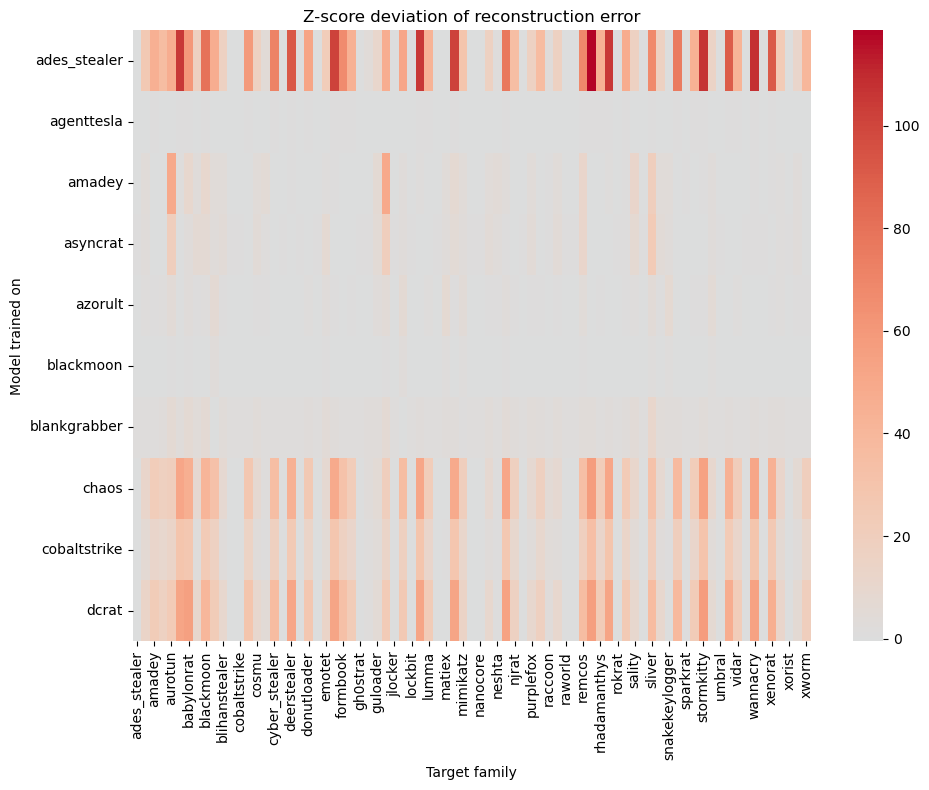

In [19]:
pivot_z = df_eval.pivot(index="model_family", columns="target_family", values="z_mean")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_z, annot=False, cmap="coolwarm", center=0)
plt.title("Z-score deviation of reconstruction error")
plt.xlabel("Target family")
plt.ylabel("Model trained on")
plt.tight_layout()
plt.show()